In [1]:
import sys
!{sys.executable} -m pip install yfinance --user


In [2]:
import yfinance as yf  
data = yf.download('AAPL', start='2020-01-01')

[*********************100%***********************]  1 of 1 completed


In [3]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400513,72.460776,71.156674,71.409778,135480400
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800
2020-01-06,72.267914,72.306483,70.568488,70.819186,118387200
2020-01-07,71.928062,72.533103,71.708703,72.277586,108872000
2020-01-08,73.085106,73.386423,71.631552,71.631552,132079200


In [4]:
data.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-04-08,258.899994,259.750000,256.529999,258.450012,41032800
2026-04-09,260.489990,261.119995,256.070007,259.000000,28121600
2026-04-10,260.480011,262.190002,259.019989,259.980011,31291500
2026-04-13,259.200012,260.179993,256.660004,259.730011,36234700
2026-04-14,258.829987,261.929993,257.190002,259.250000,48214600


In [5]:
data.shape

(1578, 5)

In [6]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1578.000000,1578.000000,1578.000000,1578.000000,1.578000e+03
mean,169.005384,170.740966,167.116954,168.862138,8.286375e+07
std,52.384624,52.741496,52.007928,52.376704,5.091171e+07
min,54.213608,55.211524,51.372088,55.110042,1.791060e+07
25%,133.152195,134.678377,131.333414,132.923605,4.952122e+07
50%,166.721756,168.066979,165.204386,166.962502,6.883675e+07
75%,208.460632,211.224723,206.552681,208.536878,9.817405e+07
max,285.922455,288.350192,283.035157,285.932471,4.265100e+08


In [7]:
# Data cleaning & preprocessing

In [8]:
data.dtypes

Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

In [9]:
data.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

In [10]:
data.duplicated().sum()

np.int64(0)

In [11]:
#Feature engineering

In [11]:
data['sma_20']=data['Close'].rolling(window=20).mean()
data['sma_50']=data['Close'].rolling(window=50).mean()


In [12]:
data['ema_20']=data['Close'].ewm(span=20,adjust=False).mean()
data['ema_50']=data['Close'].ewm(span=50,adjust=False).mean()


In [13]:
data['daily_return']=data['Close'].pct_change()*100

In [14]:
data.head()

Price,Close,High,Low,Open,Volume,sma_20,sma_50,ema_20,ema_50,daily_return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,
Date,,,,,,,,,,
2020-01-02,72.400513,72.460776,71.156674,71.409778,135480400,NaN,NaN,72.400513,72.400513,NaN
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800,NaN,NaN,72.333477,72.372910,-0.972193
2020-01-06,72.267914,72.306483,70.568488,70.819186,118387200,NaN,NaN,72.327233,72.368792,0.796793
2020-01-07,71.928062,72.533103,71.708703,72.277586,108872000,NaN,NaN,72.289217,72.351509,-0.470266
2020-01-08,73.085106,73.386423,71.631552,71.631552,132079200,NaN,NaN,72.365016,72.380277,1.608612


In [16]:
# EDA

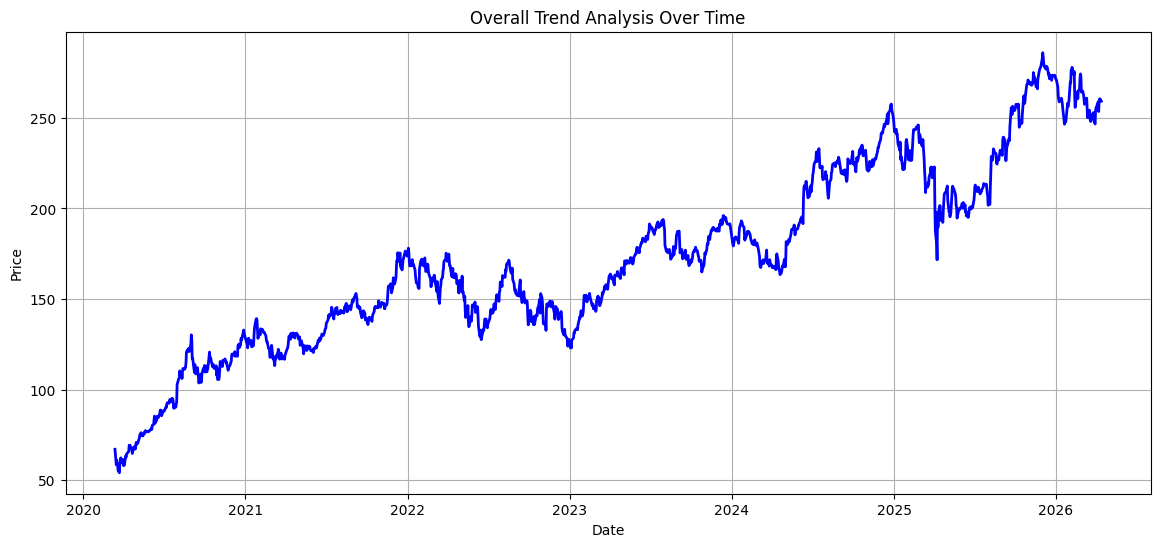

In [31]:
# Overall Trend Analysis

import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
plt.plot(data['Close'],label='Price',color='blue',linewidth=2)
plt.title('Overall Trend Analysis Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()

In [32]:
'''
#Insights

- The stock shows an overall upward trend overtime.

- Also shows a remarkable growth overtime from price of nearly 70 to 280 from Year 2020 to 2026

- It can also be observed that whenever the stock price went down, it recovered higher than before
which shows the stock's attribute of being a long term and fundamentally strong stock
'''

"\n#Insights\n\n- The stock shows an overall upward trend overtime.\n\n- Also shows a remarkable growth overtime from price of nearly 70 to 280 from Year 2020 to 2026\n\n- It can also be observed that whenever the stock price went down, it recovered higher than before\nwhich shows the stock's attribute of being a long term and fundamentally strong stock\n"

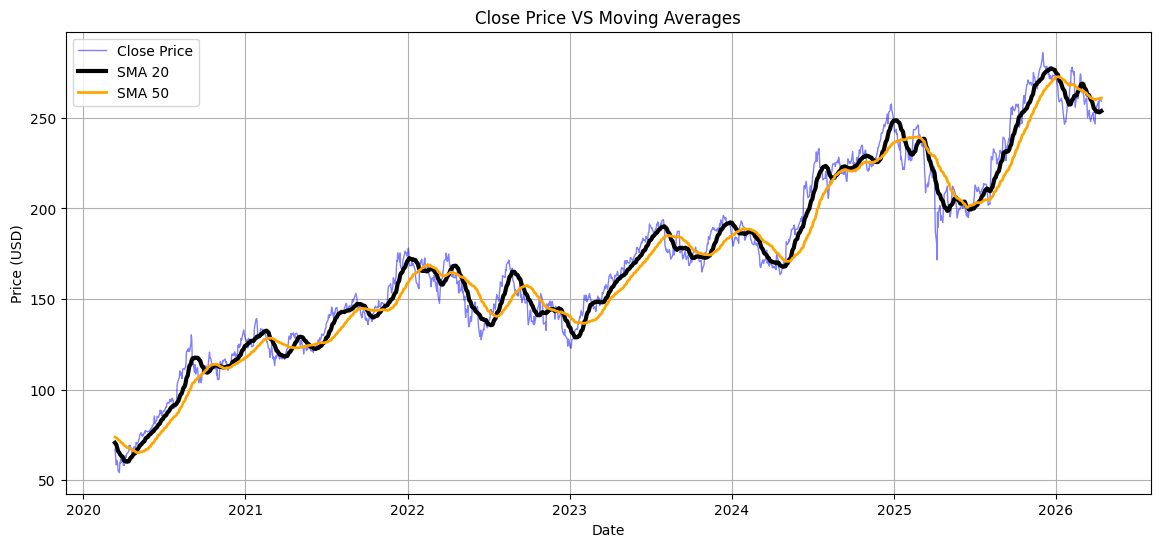

In [33]:
# Closing price v/s moving average

import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
plt.plot(data['Close'],label='Close Price',color='blue',alpha=0.5,linewidth=1)
plt.plot(data['sma_20'],label='SMA 20',color='black',linewidth=3)
plt.plot(data['sma_50'],label='SMA 50',color='orange',linewidth=2)
plt.title('Close Price VS Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [34]:
'''
Insights:

- Price is consistently staying above MA that is indicating a bullish trend

- Also simple moving average of 20 days and simple moving average of 50 days are moving very close
to each other throughout the period which is showing a stable and consistent trend without any 
major crossover signals
'''

'\nInsights:\n\n- Price is consistently staying above MA that is indicating a bullish trend\n\n- Also simple moving average of 20 days and simple moving average of 50 days are moving very close\nto each other throughout the period which is showing a stable and consistent trend without any \nmajor crossover signals\n'

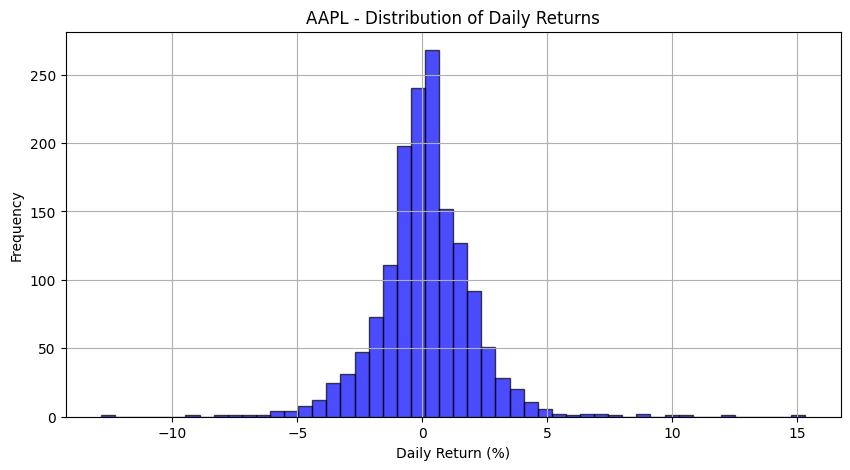

In [35]:
#Volatility Analysis
plt.figure(figsize=(10, 5))
plt.hist(data['daily_return'].dropna(), bins=50, color='blue', edgecolor='black', alpha=0.7)
plt.title('AAPL - Distribution of Daily Returns')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [36]:
'''
Insights:

-Daily returns are concentrated between -5% to 5% states that on a typical day AAPL rarely moves
more than 5% in either direction

- Rare extreme events beyond ±10% exist but are very infrequent, suggesting they were driven by 
specific news events rather than regular market behavior.

- Also centered slightly above 0%, confirming a positive bias with low volatility

'''

'\nInsights:\n\n-Daily returns are concentrated between -5% to 5% states that on a typical day AAPL rarely moves\nmore than 5% in either direction\n\n- Rare extreme events beyond ±10% exist but are very infrequent, suggesting they were driven by \nspecific news events rather than regular market behavior.\n\n- Also centered slightly above 0%, confirming a positive bias with low volatility\n\n'

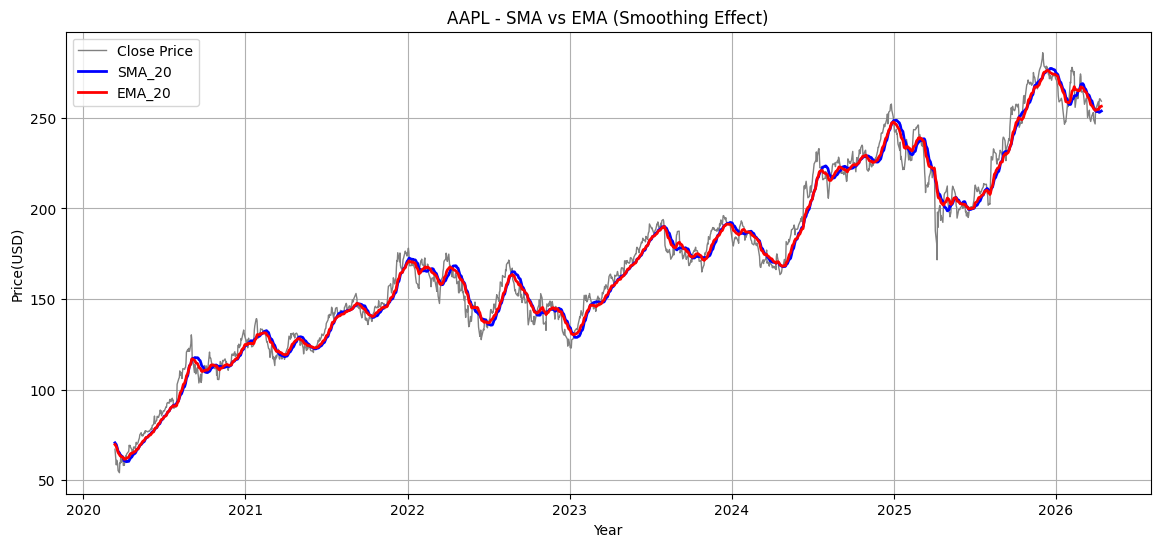

In [37]:
#EMA V/S MA

plt.figure(figsize=(14,6))
plt.plot(data['Close'], label='Close Price', color='grey',linewidth=1)
plt.plot(data['sma_20'],label='SMA_20',color='blue',linewidth=2)
plt.plot(data['ema_20'],label='EMA_20',color='red',linewidth=2)
plt.title('AAPL - SMA vs EMA (Smoothing Effect)')
plt.xlabel('Year')
plt.ylabel('Price(USD)')
plt.legend()
plt.grid(True)
plt.show()


In [38]:
'''
Insights:

-AAPL shows a strong long term uptrend from ~$75 in 2020 to ~$250 in 2026, with EMA_20 consistently
hugging the Close price more tightly than SMA_20, confirming EMA's faster reaction to price 
movements during both rallies and dips
'''

"\nInsights:\n\n-AAPL shows a strong long term uptrend from ~$75 in 2020 to ~$250 in 2026, with EMA_20 consistently\nhugging the Close price more tightly than SMA_20, confirming EMA's faster reaction to price \nmovements during both rallies and dips\n"

In [39]:
#Prediction Model

In [24]:
data.head()

Price,Close,High,Low,Open,Volume,sma_20,sma_50,ema_20,ema_50,daily_return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,
Date,,,,,,,,,,
2020-01-02,72.400513,72.460776,71.156674,71.409778,135480400,NaN,NaN,72.400513,72.400513,NaN
2020-01-03,71.696640,72.455958,71.472462,71.629145,146322800,NaN,NaN,72.333477,72.372910,-0.972193
2020-01-06,72.267914,72.306483,70.568488,70.819186,118387200,NaN,NaN,72.327233,72.368792,0.796793
2020-01-07,71.928062,72.533103,71.708703,72.277586,108872000,NaN,NaN,72.289217,72.351509,-0.470266
2020-01-08,73.085106,73.386423,71.631552,71.631552,132079200,NaN,NaN,72.365016,72.380277,1.608612


In [26]:
data['Target']=data['Close'].shift(-1)

In [27]:
data['prev_close'] = data['Close'].shift(1)

In [29]:
data=data.dropna()

In [30]:
data.head()

Price,Close,High,Low,Open,Volume,sma_20,sma_50,ema_20,ema_50,daily_return,Target,prev_close
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,,
Date,,,,,,,,,,,,
2020-03-13,67.164749,67.635923,61.119268,64.004286,370732000,70.707838,73.801323,69.770888,72.242214,11.980805,58.524223,59.978806
2020-03-16,58.524223,62.600448,57.990228,58.461398,322423600,69.708232,73.523797,68.699777,71.704254,-12.864674,61.097530,67.164749
2020-03-17,61.097530,62.245250,57.603618,59.804830,324056000,68.909175,73.311815,67.975754,71.288304,4.396995,59.601860,58.524223
2020-03-18,59.601860,60.406475,57.294332,57.934643,300233600,67.979521,73.058494,67.178240,70.830012,-2.448005,59.145184,61.097530
2020-03-19,59.145184,61.092688,58.620856,59.775827,271857200,67.067140,72.802837,66.413187,70.371783,-0.766212,55.390339,59.601860


In [40]:
x=data[['prev_close','sma_20','sma_50','ema_20','ema_50']]
y=data['Target']

In [41]:
split_idx = int(0.8 * len(data))
x_train = x.iloc[:split_idx].copy()
x_test = x.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test = y.iloc[split_idx:].copy()

In [42]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [43]:
y_pred=model.predict(x_test)

In [44]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'MAE  : {mae:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'R2   : {r2:.2f}')

MAE  : 4.34
RMSE : 6.30
R2   : 0.95


In [51]:
avg_price = y_test.mean()
mae_pct = (mae / avg_price) * 100
print(f'MAE as % of avg price: {mae_pct:.2f}%')

MAE as % of avg price: 1.83%


In [46]:
#

In [47]:
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor(n_estimators=100,random_state=42,max_depth=None,min_samples_split=5 )
rf_model.fit(x_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [48]:
rf_ypred=rf_model.predict(x_test)
rf_mae = mean_absolute_error(y_test, rf_ypred)
rf_rmse = np.sqrt(mean_squared_error(y_test,rf_ypred))
rf_r2 = r2_score(y_test, rf_ypred)

print(f'MAE  : {rf_mae:.2f}')
print(f'RMSE : {rf_rmse:.2f}')
print(f'R2   : {rf_r2:.2f}')

MAE  : 11.58
RMSE : 14.87
R2   : 0.70


In [50]:
print(x_train.corrwith(y_train).sort_values(key=abs, ascending=False))

Price       Ticker
prev_close            0.995609
ema_20                0.988630
sma_20                0.984970
ema_50                0.976361
sma_50                0.966912
dtype: float64


In [ ]:
data['Predicted_Price']=model.predict(x) #for using in power bi

In [ ]:
data.to_csv('aapl_analysis.csv',index=True)